# <a id='toc1_'></a>[Hyperparameter Tuning of 1D conv net](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Hyperparameter Tuning of 1D conv net](#toc1_)    
  - [Import](#toc1_1_)    
  - [Setup](#toc1_2_)    
  - [Upload](#toc1_3_)    
  - [Splitting + augmentation + saving](#toc1_4_)    
  - [Scaling + saving](#toc1_5_)    
  - [Creation lag features table with n_input_step fixed](#toc1_6_)    
    - [Iperparametri Architetturali (Specifici CNN)](#toc1_6_1_)    
    - [Iperparametri Strutturali (Simili all'MLP)](#toc1_6_2_)    
    - [Iperparametri di Training (Identici all'MLP)](#toc1_6_3_)    
  - [Definition of search space = objective function for RandomSearch and Optuna](#toc1_7_)    
  - [Future preds - REFITTING ON FULL TIME SERIES](#toc1_8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

## <a id='toc1_1_'></a>[Import](#toc0_)

In [2]:
from src.config import set_seeds, get_complete_path, MODELS_DIR, SAFE_VAR_NAME, RANDOM_SEED
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd
import tensorflow as tf
import numpy as np
import os
import gc
import optuna
import pickle
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore
from optuna_integration.tfkeras import TFKerasPruningCallback
from optuna.samplers import RandomSampler, TPESampler
from sklearn.preprocessing import MinMaxScaler

## <a id='toc1_2_'></a>[Setup](#toc0_)

In [3]:
INDICATORS = ['Fertilizer consumption (% of fertilizer production)']

DF_CATEGORIES = ['orig', 'step_aug', 'jitter_aug']

set_seeds()
# 'Livestock production index (2014-2016 = 100)'

## <a id='toc1_3_'></a>[Upload](#toc0_)

In [4]:
df = pipe.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## <a id='toc1_4_'></a>[Splitting + augmentation + saving](#toc0_)

============================== FERTILIZER CONSUMPTION (% OF FERTILIZER PRODUCTION) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\AUGMENTATION\AUG_fertilizer_percent.png


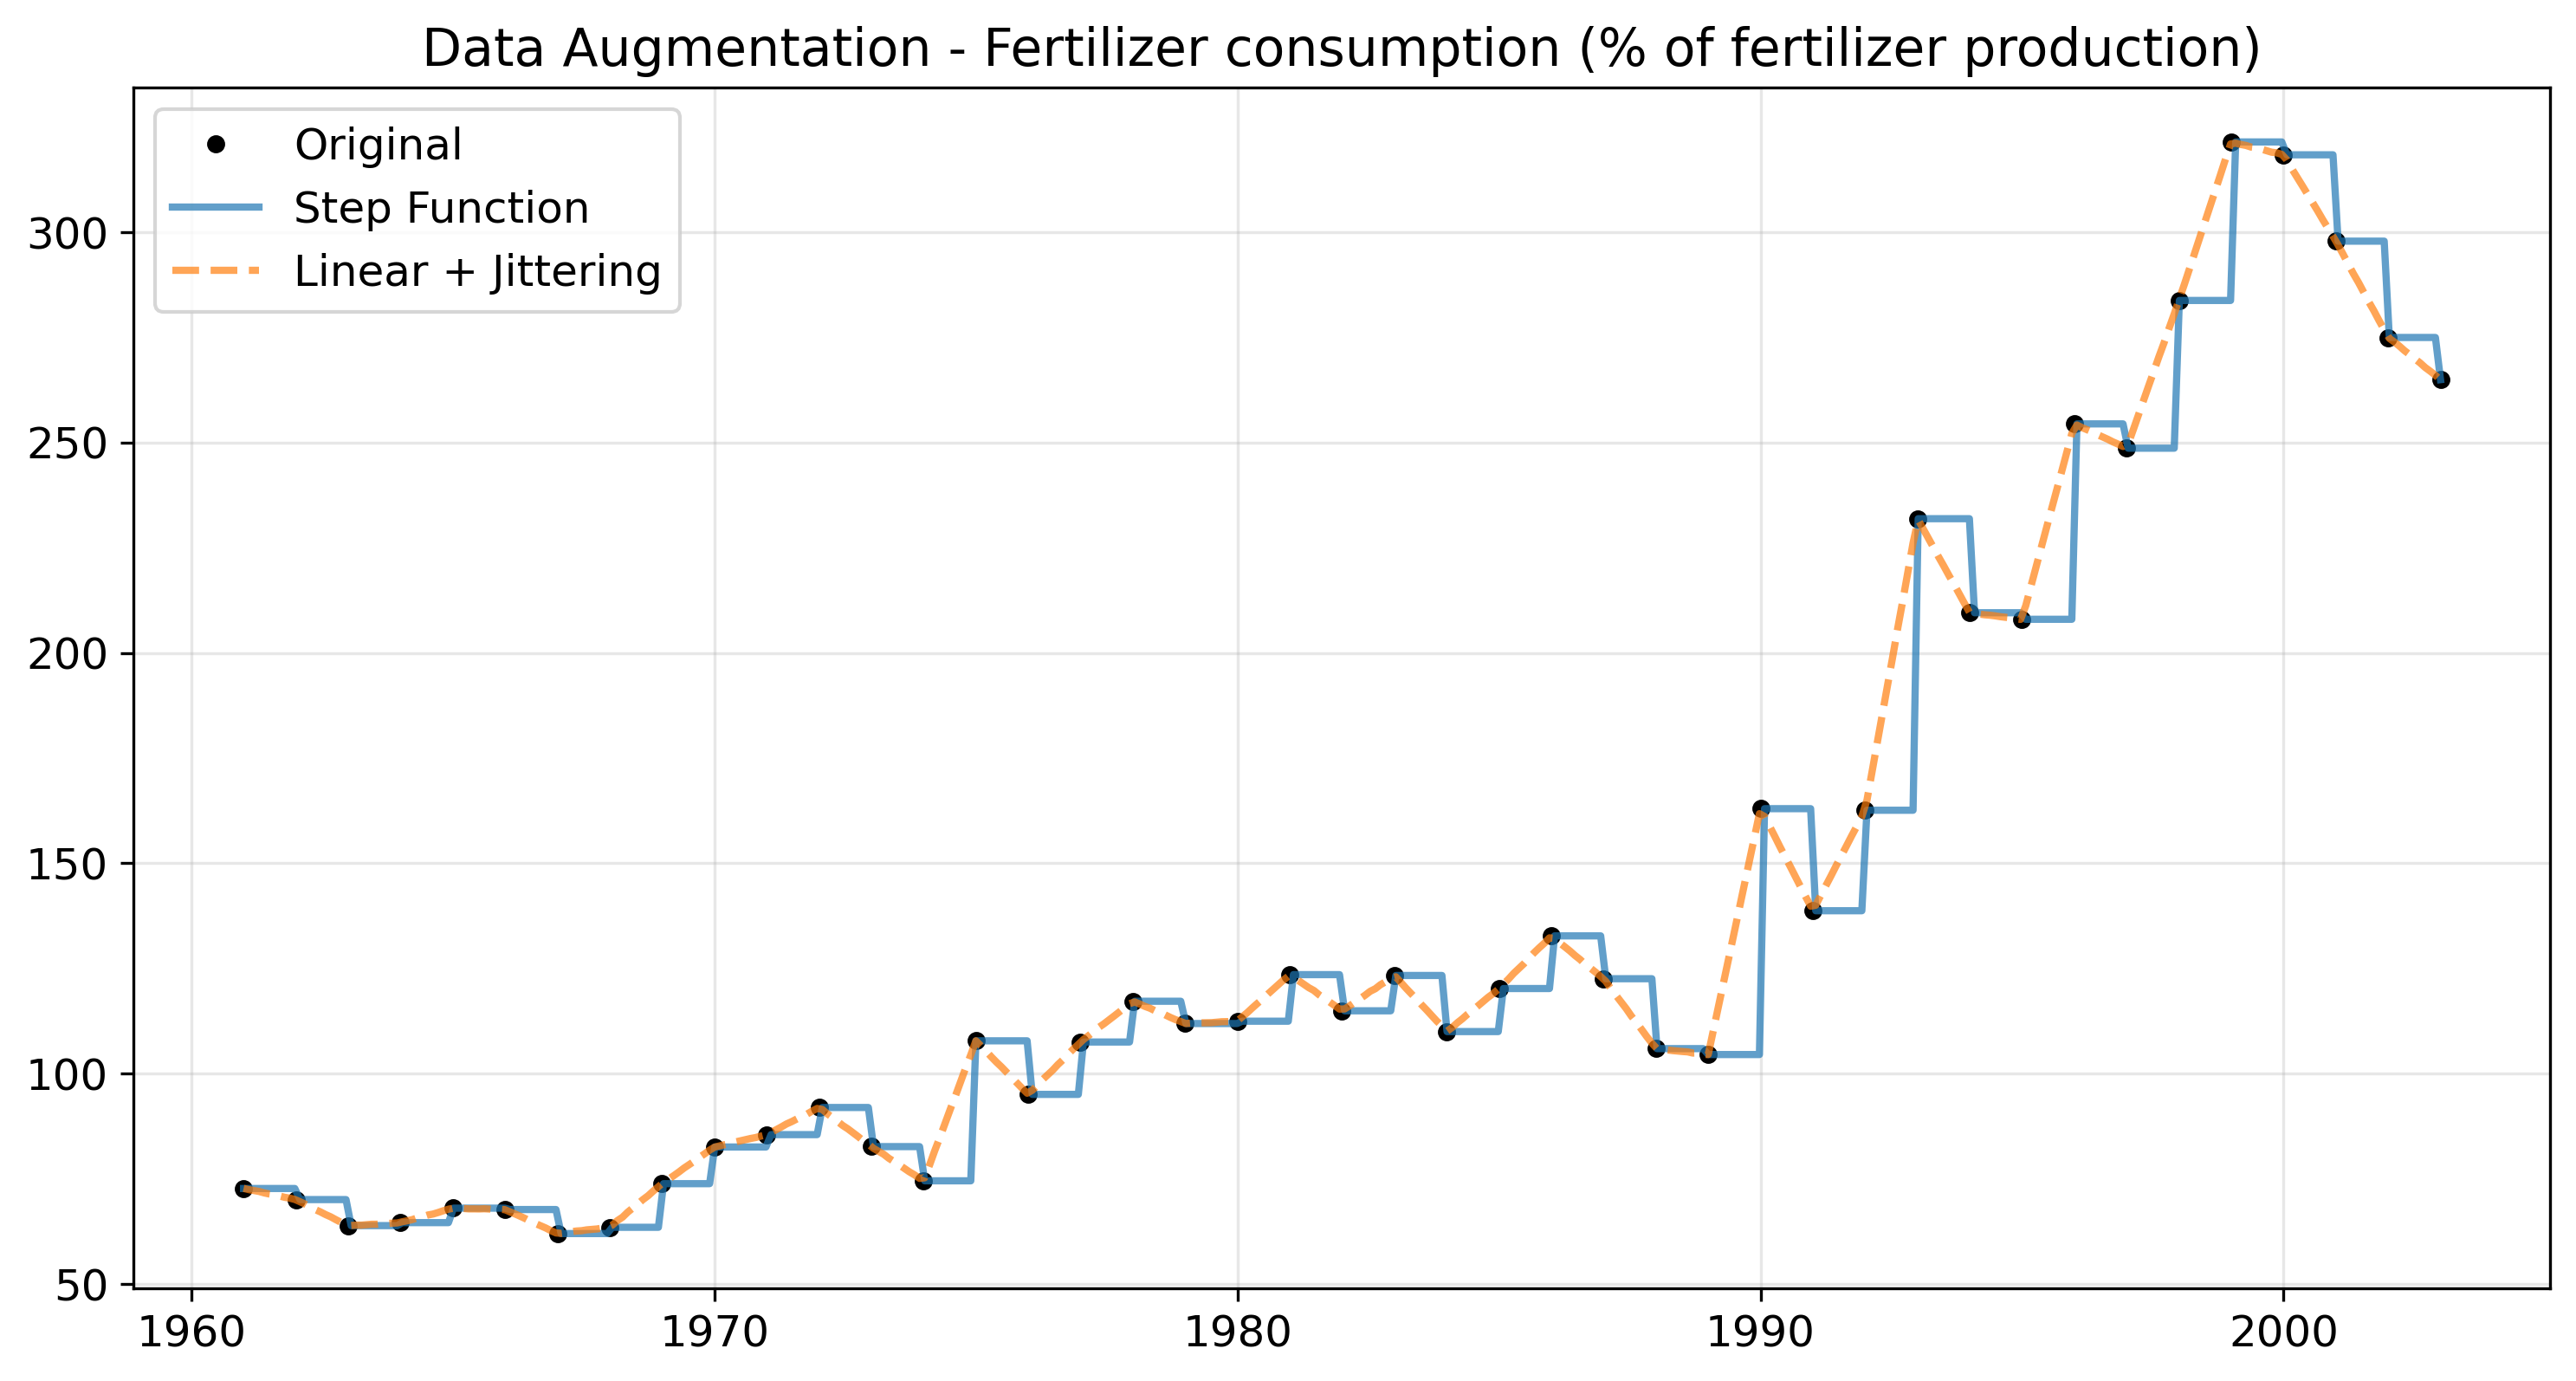

In [5]:
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

## <a id='toc1_5_'></a>[Scaling + saving](#toc0_)

In [6]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}
for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

## <a id='toc1_6_'></a>[Creation lag features table with window size fixed](#toc0_)

In [7]:
scaled_table_subsets = {}
for indicator in INDICATORS:
    window_size = 3
    table_train_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_train'], window_size, step=1)
    table_train_step = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['step_aug_train'], window_size, step=1)
    table_train_jitter = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['jitter_aug_train'], window_size, step=1)
    table_val_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_val'], window_size, step=1)
    table_test_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_test'], window_size, step=1)
    scaled_table_subsets[indicator] = {
        'train_orig' : table_train_orig,
        'train_step' : table_train_step,
        'train_jitter' : table_train_jitter,
        'val_orig' : table_val_orig,
        'test_orig' : table_test_orig
    }

In [8]:
final_table_train_sets = {}
final_table_val_test_sets = {}

for indicator in INDICATORS:
    # X: filtra colonne ts_*
    # y: prende colonna 'target'
    X_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig'].filter(regex=r'^ts_').copy()
    y_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig']['target'].copy()
    
    X_train_step_to_reshape = scaled_table_subsets[indicator]['train_step'].filter(regex=r'^ts_').copy()
    y_train_step_to_reshape = scaled_table_subsets[indicator]['train_step']['target'].copy()
    
    X_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter'].filter(regex=r'^ts_').copy()
    y_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter']['target'].copy()
    
    X_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig'].filter(regex=r'^ts_').copy()
    y_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig']['target'].copy()
    
    X_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig'].filter(regex=r'^ts_').copy()
    y_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig']['target'].copy()
    
    # Reshape X: (samples, window_size, 1)
    X_train_orig = X_train_orig_to_reshape.values.reshape((X_train_orig_to_reshape.shape[0], X_train_orig_to_reshape.shape[1], 1))
    X_train_step = X_train_step_to_reshape.values.reshape((X_train_step_to_reshape.shape[0], X_train_step_to_reshape.shape[1], 1))
    X_train_jitter = X_train_jitter_to_reshape.values.reshape((X_train_jitter_to_reshape.shape[0], X_train_jitter_to_reshape.shape[1], 1))
    X_val_orig = X_val_orig_to_reshape.values.reshape((X_val_orig_to_reshape.shape[0], X_val_orig_to_reshape.shape[1], 1))
    X_test_orig = X_test_orig_to_reshape.values.reshape((X_test_orig_to_reshape.shape[0], X_test_orig_to_reshape.shape[1], 1))
    
    # Reshape y: (samples, 1)
    y_train_orig = y_train_orig_to_reshape.values.reshape(-1, 1)
    y_train_step = y_train_step_to_reshape.values.reshape(-1, 1)
    y_train_jitter = y_train_jitter_to_reshape.values.reshape(-1, 1)
    y_val_orig = y_val_orig_to_reshape.values.reshape(-1, 1)
    y_test_orig = y_test_orig_to_reshape.values.reshape(-1, 1)
    
    final_table_train_sets[indicator] = {
        'train_orig' : (X_train_orig, y_train_orig),
        'train_step' : (X_train_step, y_train_step),
        'train_jitter' : (X_train_jitter, y_train_jitter),
    }
    
    final_table_val_test_sets[indicator] = {
        'val_orig': (X_val_orig, y_val_orig),
        'test_orig' : (X_test_orig, y_test_orig)
    }
    
    # print("train orig", X_train_orig[0], y_train_orig[0])
    # print("step", X_train_step[0], y_train_step[0])
    # print("jitter", X_train_jitter[0], y_train_jitter[0])
    # print("val", X_val_orig[0], y_val_orig[0])
    # print("test", X_test_orig[0], y_test_orig[0])

### <a id='toc1_6_1_'></a>[Iperparametri Architetturali (Specifici CNN)](#toc0_)
- **Number of Filters**: [16, 32, 64, 128]. Più filtri = più capacità di vedere dettagli, ma più rischio overfitting.
- **Kernel Size**: [3, 5, 7].
    - Piccolo (3): Vede dettagli fini/rumore ad alta frequenza.
    - Grande (7): Vede trend più ampi/lisciati.
- **Pooling Type**: [MaxPooling, AveragePooling, None]. A volte con soli 60 punti, non fare pooling è meglio (o usare "Global Average Pooling" alla fine).
- **Number of Conv Blocks**: [1, 2].
<br>
Attenzione: Se metti 3 layer di pooling (diviso 2 tre volte), 60 diventa 7.5 -> 7 punti. Con 4 layer arrivi a 3 punti. Optuna deve sapere di non esagerare con la profondità su serie corte.

### <a id='toc1_6_2_'></a>[Iperparametri Strutturali (Simili all'MLP)](#toc0_)
- **Dense Layer Size**: quanti neuroni nel layer dopo il Flatten.
- **Dropout Rate**: [0.2 - 0.5] dopo la convoluzione o dopo il dense layer.

### <a id='toc1_6_3_'></a>[Iperparametri di Training (Identici all'MLP)](#toc0_)
- **Learning Rate**.
- **Batch Size**.
- **Optimizer** (Adam, RMSprop, ecc.).

Per una CNN, spesso servono finestre più ampie rispetto a un MLP per catturare pattern

## <a id='toc1_7_'></a>[Definition of search space = objective function for RandomSearch and Optuna](#toc0_)

In [ ]:
def objective(trial, scaled_data_dict):
    n_input_steps = trial.suggest_int('n_input_steps', 3, 6) 
    
    # Search Space
    params = {
        # Struttura Convoluzionale
        'n_conv_layers': trial.suggest_int('n_conv_layers', 1, 2),      # Numero di blocchi Conv
        'filters': trial.suggest_categorical('filters', [16, 32, 64]),
        'kernel_size': trial.suggest_int('kernel_size', 2, 4),          # Quanto è grande la "lente" della conv
        'pool_size': 2,                                                 # volendo posso tunarlo (es. suggest_int(2,3))
        
        # Struttura Dense (Head della rete)
        'dense_units': trial.suggest_int('dense_units', 16, 64),
        'activation': 'relu', # Relu è standard per CNN, ma posso usare trial.suggest nel caso
        
        # Training
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4),
        'input_shape': (n_input_steps, 1)
    }
    
    # Check di sicurezza: il kernel non può essere più grande dell'input
    if params['kernel_size'] >= n_input_steps:
        raise optuna.TrialPruned()
    
    train_data = scaled_data_dict['train']
    val_data = scaled_data_dict['val']
    
    X_train, y_train = pipe.create_sequences(train_data['Value'], n_input_steps)
    X_val, y_val = pipe.create_sequences(val_data['Value'], n_input_steps)
    
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned()
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

    model = nn.build_cnn_model(params) 
    
    pruning_callback = TFKerasPruningCallback(trial, "val_loss")
    
    history, model = nn.train_model(    
        model, 
        X_train, y_train, 
        X_val, y_val,
        batch_size=params['batch_size'],
        epochs=50, 
        patience=10,
        extra_callbacks=[pruning_callback]
    )
    
    if 'val_loss' not in history.history:
        return float('inf')
        
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss

In [10]:
tuning_results = []
BACKUP_FILE = "tuning_results_cnn_backup.pkl"
N_TRIALS = 20

pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=50, reduction_factor=3)

for SAMPLER_MODE in ["Random", "TPE"]:
    for indicator in INDICATORS:
        print(f"\n{'='*40} PROCESSING: {indicator} [{SAMPLER_MODE}] {'='*40}")
        
        for df_category in DF_CATEGORIES:
            print(f"\n Optimizing: {df_category}")
            
            if SAMPLER_MODE == "Random":
                sampler = RandomSampler(seed=42)
            else:
                sampler = TPESampler(seed=42, n_startup_trials=10) 
        
            try:
                data_package = {
                    'train': scaled_orig_aug_subsets[indicator][f'{df_category}_train'],
                    'val': scaled_orig_aug_subsets[indicator]['orig_val']
                }
            except KeyError as e:
                print(f"Data Error: dataset {e} missing for {indicator}. Skipping.")
                continue
            
            safe_var = SAFE_VAR_NAME.get(indicator, indicator[:3])
            safe_var = "".join([c if c.isalnum() else "_" for c in safe_var])[:50]
            
            study_name = f"CNN_{safe_var}_{df_category}_{SAMPLER_MODE}"
            study = optuna.create_study(
                direction='minimize', 
                sampler=sampler, 
                pruner=pruner,
                study_name=study_name
            )
            
            try:
                study.optimize(
                    lambda trial: objective(trial, data_package), 
                    n_trials=N_TRIALS,
                    gc_after_trial=True # Pulisce la memoria dopo ogni trial
                )
            except Exception as e:
                print(f"Optuna crash on {indicator} - {df_category}: {e}")
                continue

            result_entry = {
                "indicator": indicator,
                "sampler": SAMPLER_MODE,
                "dataset_type": df_category,
                "best_params": study.best_params,
                "best_val_loss": study.best_value,
                "n_trials": N_TRIALS,
                "model_type": "CNN"
            }
            
            tuning_results.append(result_entry)
            print(f"Saved params for {indicator} ({df_category}) -> Loss: {study.best_value:.5f}")

            with open(BACKUP_FILE, "wb") as f:
                pickle.dump(tuning_results, f)
            
            tf.keras.backend.clear_session()
            gc.collect()

print(f"\nOptimal params found for {len(tuning_results)} configurations.")

[I 2025-12-16 15:47:05,355] A new study created in memory with name: CNN_fertilizer_percent_orig_Random



======================================== PROCESSING: Fertilizer consumption (% of fertilizer production) [Random] ========================================

 Optimizing: orig


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-12-16 15:47:11,799] Trial 0 finished with value: 0.11353156715631485 and parameters: {'n_input_steps': 4, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074}. Best is trial 0 with value: 0.11353156715631485.
[I 2025-12-16 15:47:17,379] Trial 1 finished with value: 0.026976928114891052 and parameters: {'n_input_steps': 6, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 41, 'learning_rate': 0.0007309539835912913, 'batch_size': 32, 'dropout': 0.14184815819561256}. Best is t

Saved params for Fertilizer consumption (% of fertilizer production) (orig) -> Loss: 0.02146


 Optimizing: step_aug


[I 2025-12-16 15:48:15,744] A new study created in memory with name: CNN_fertilizer_percent_step_aug_Random
[I 2025-12-16 15:48:18,801] Trial 0 finished with value: 0.2876647412776947 and parameters: {'n_input_steps': 4, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074}. Best is trial 0 with value: 0.2876647412776947.
[I 2025-12-16 15:48:22,142] Trial 1 finished with value: 0.028573088347911835 and parameters: {'n_input_steps': 6, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 41, 'learning_rate': 0.0007309539835912913, 'batch_size': 32, 'dropout': 0.14184815819561256}. Best is trial 1 with value: 0.028573088347911835.
[I 2025-12-16 15:48:26,132] Trial 2 finished with value: 0.04771633446216583 and parameters: {'n_input_steps': 4, 'n_conv_layers': 1, 'filters': 32, 'kernel_size': 3, 'dense_units': 45, 'learning_rate': 0.0001238513729886094, 'batch_size': 1

...

Saved params for Fertilizer consumption (% of fertilizer production) (step_aug) -> Loss: 0.01552


[I 2025-12-16 15:52:35,024] A new study created in memory with name: CNN_fertilizer_percent_jitter_aug_TPE



 Optimizing: jitter_aug


[I 2025-12-16 15:52:38,036] Trial 0 finished with value: 0.341806024312973 and parameters: {'n_input_steps': 4, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 18, 'learning_rate': 0.005399484409787433, 'batch_size': 32, 'dropout': 0.10617534828874074}. Best is trial 0 with value: 0.341806024312973.
[I 2025-12-16 15:52:41,735] Trial 1 finished with value: 0.04500987380743027 and parameters: {'n_input_steps': 6, 'n_conv_layers': 2, 'filters': 16, 'kernel_size': 2, 'dense_units': 41, 'learning_rate': 0.0007309539835912913, 'batch_size': 32, 'dropout': 0.14184815819561256}. Best is trial 1 with value: 0.04500987380743027.
[I 2025-12-16 15:52:45,239] Trial 2 finished with value: 0.08063703775405884 and parameters: {'n_input_steps': 4, 'n_conv_layers': 1, 'filters': 32, 'kernel_size': 3, 'dense_units': 45, 'learning_rate': 0.0001238513729886094, 'batch_size': 16, 'dropout': 0.11951547789558387}. Best is trial 1 with value: 0.04500987380743027.
[I 2025-12-16 15:52:48,590]

Saved params for Fertilizer consumption (% of fertilizer production) (jitter_aug) -> Loss: 0.01275

Optimal params found for 6 configurations.


In [11]:
predictions_dict = {}
print(f"Refitting on {len(tuning_results)} CNN configurations.")

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

for entry in tuning_results:
    ind = entry['indicator']
    sampler = entry['sampler']
    ds_type = entry['dataset_type']
    
    params = entry['best_params'].copy()
    
    print(f"\nRefitting: {ind} | {sampler} | {ds_type} ...")
    
    scaler_y = scalers_subsets[ind]['scaler_y']
    train_df = scaled_orig_aug_subsets[ind][f'{ds_type}_train']
    val_df = scaled_orig_aug_subsets[ind]['orig_val']
    test_df = scaled_orig_aug_subsets[ind]['orig_test']
    
    n_steps = params['n_input_steps']
    
    X_train, y_train = pipe.create_sequences(train_df['Value'], n_steps)
    X_val, y_val = pipe.create_sequences(val_df['Value'], n_steps)
    X_test, y_test = pipe.create_sequences(test_df['Value'], n_steps)
    
    if len(X_test) == 0:
        print(f"SKIP {ind} - {ds_type}: test set is too short for window {n_steps}")
        continue

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    params['input_shape'] = (n_steps, 1)
    
    model = nn.build_cnn_model(params)
    
    history, model = nn.train_model(
        model, X_train, y_train, X_val, y_val, 
        batch_size=params['batch_size'], 
        epochs=150, 
        patience=20
    )
    
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_real = scaler_y.inverse_transform(y_test).flatten()
    
    aligned_years = test_df['Year'].values[n_steps:]
    
    if len(aligned_years) != len(y_test_real):
        print(f"ERROR year dimension: expected {len(y_test_real)}, found {len(aligned_years)}")
        continue

    if ind not in predictions_dict: predictions_dict[ind] = {}
    if sampler not in predictions_dict[ind]: predictions_dict[ind][sampler] = {}
    
    predictions_dict[ind][sampler][ds_type] = {
        'years': aligned_years,
        'y_true': y_test_real,
        'y_pred': y_pred_real,
        'params': params,
        'metrics': eval.compute_errors(y_test_real, y_pred_real)
    }
    
    residuals, stats = eval.compute_residuals(y_test_real, y_pred_real)
    
    rep.log_experiment_results(
        indicator=ind,
        model_type="CNN",
        config_name=f"{sampler}_{ds_type}",
        metrics=eval.compute_errors(y_test_real, y_pred_real),
        best_params=params,
        residuals_stats=stats
    )
    
    print("DONE")
    
    tf.keras.backend.clear_session()
    del model
    gc.collect()

print("\nCompleted CNN refitting. Results saved in predictions_dict.")

Refitting on 6 CNN configurations.

Refitting: Fertilizer consumption (% of fertilizer production) | Random | orig ...
Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | Random | step_aug ...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | Random | jitter_aug ...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | TPE | orig ...


...

Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | TPE | step_aug ...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | TPE | jitter_aug ...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (% of fertilizer production)
DONE

Completed CNN refitting. Results saved in predictions_dict.



Plotting predictions for: Fertilizer consumption (% of fertilizer production)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\CNN\CNN_fertilizer_percent.png


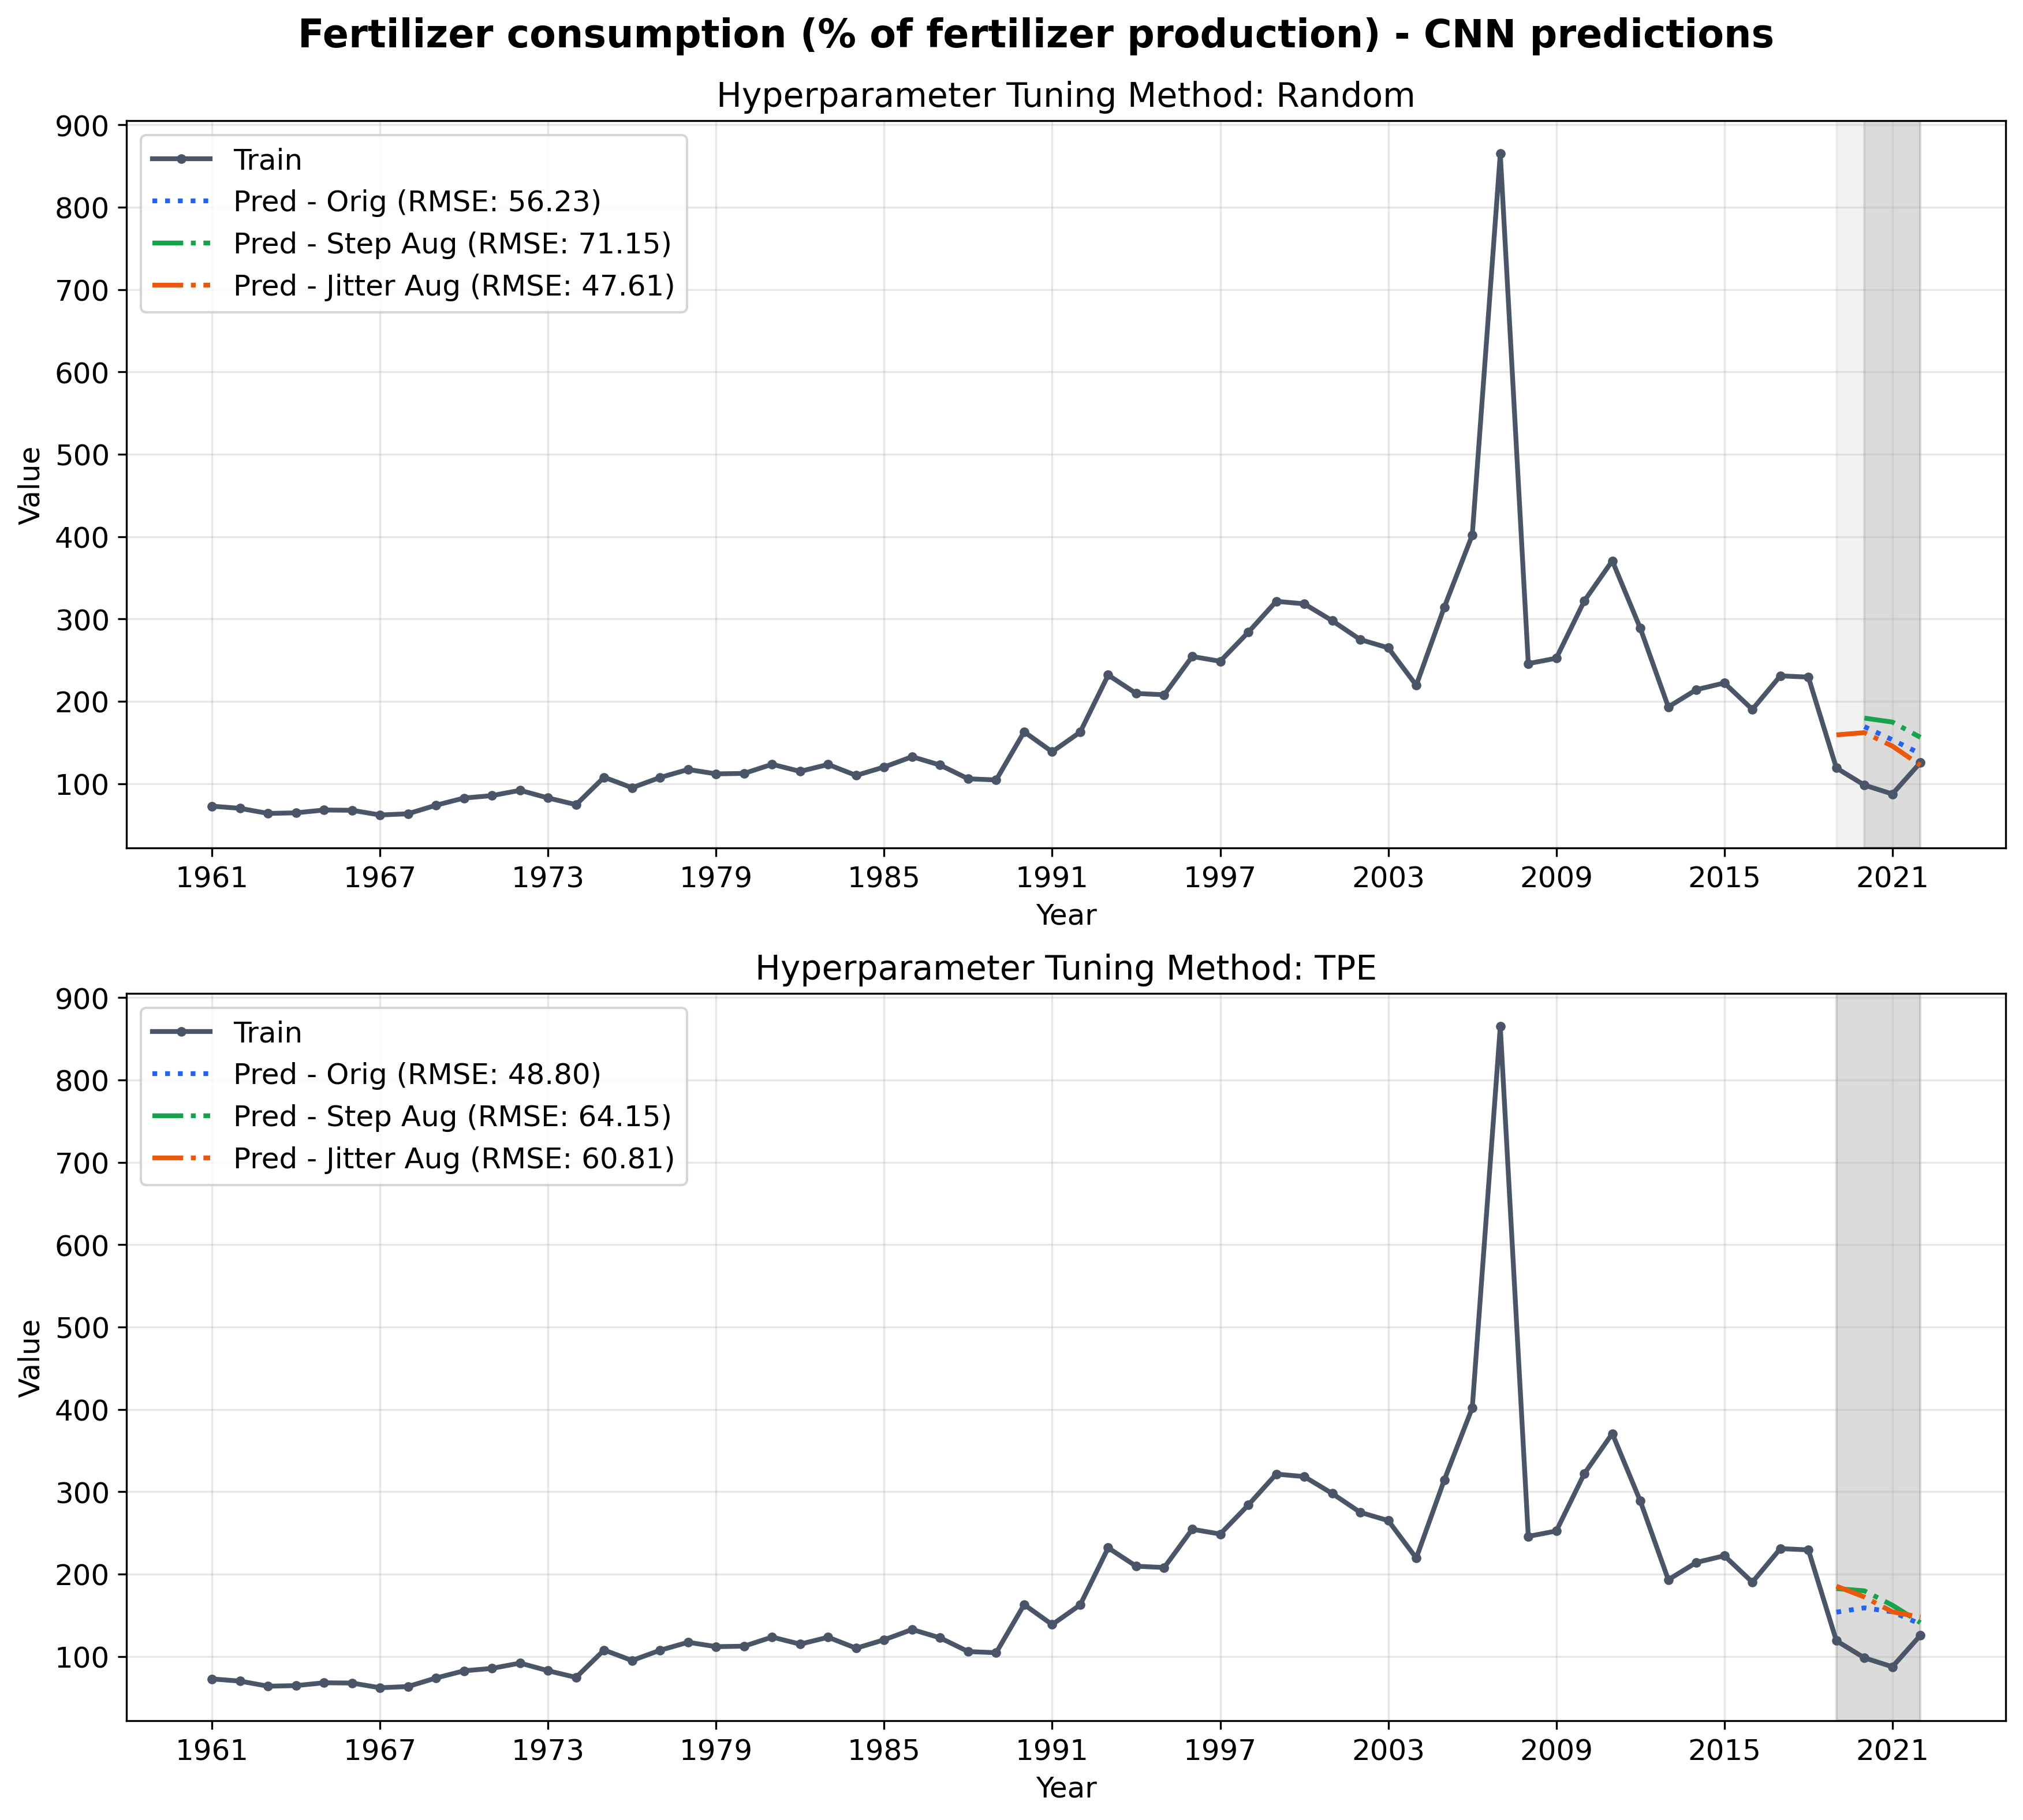

Random | orig -> years: [2020, 2021, 2022] preds: [169.26449584960938, 153.26300048828125, 136.49090576171875]
Random | step_aug -> years: [2020, 2021, 2022] preds: [179.65469360351562, 174.79550170898438, 156.2677001953125]
Random | jitter_aug -> years: [2019, 2020, 2021, 2022] preds: [159.23399353027344, 161.9763946533203, 145.69419860839844, 122.34590148925781]
TPE | orig -> years: [2019, 2020, 2021, 2022] preds: [153.789306640625, 159.00900268554688, 154.14939880371094, 139.37159729003906]
TPE | step_aug -> years: [2019, 2020, 2021, 2022] preds: [182.41580200195312, 179.6822052001953, 162.22540283203125, 141.10049438476562]
TPE | jitter_aug -> years: [2019, 2020, 2021, 2022] preds: [185.34390258789062, 172.2135009765625, 154.18629455566406, 147.68479919433594]


In [12]:
for indicator in INDICATORS:
    if indicator not in orig_aug_subsets:
        print(f"Skipping {indicator}: missing orig_aug_subsets")
        continue

    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing one of orig_train/orig_val/orig_test")
        continue

    if indicator not in predictions_dict:
        print(f"Skipping {indicator}: no predictions available")
        continue

    print(f"\nPlotting predictions for: {indicator}")
    visual.plot_nn_preds(
        indicator,
        predictions_dict,
        train_orig,
        val_orig,
        test_orig,
        model_name="CNN"
    )

    for sampler, cats in predictions_dict[indicator].items():
        for cat, res in cats.items():
            yrs = res.get("years")
            vals = res.get("y_pred")
            if yrs is None or vals is None:
                print(f"{sampler} | {cat}: missing years or preds")
            else:
                print(f"{sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals,4).tolist()}")

## <a id='toc1_8_'></a>[Future preds - REFITTING ON FULL TIME SERIES](#toc0_)

provo a fare predizioni prendendo come train set tutta la time serie, no validation set.

In [13]:
display(tuning_results)

[{'indicator': 'Fertilizer consumption (% of fertilizer production)',
  'sampler': 'Random',
  'dataset_type': 'orig',
  'best_params': {'n_input_steps': 6,
   'n_conv_layers': 1,
   'filters': 64,
   'kernel_size': 4,
   'dense_units': 16,
   'learning_rate': 0.0010572705046816896,
   'batch_size': 32,
   'dropout': 0.15230992870149745},
  'best_val_loss': 0.021461201831698418,
  'n_trials': 20,
  'model_type': 'CNN'},
 {'indicator': 'Fertilizer consumption (% of fertilizer production)',
  'sampler': 'Random',
  'dataset_type': 'step_aug',
  'best_params': {'n_input_steps': 6,
   'n_conv_layers': 2,
   'filters': 16,
   'kernel_size': 2,
   'dense_units': 41,
   'learning_rate': 0.0007309539835912913,
   'batch_size': 32,
   'dropout': 0.14184815819561256},
  'best_val_loss': 0.028573088347911835,
  'n_trials': 20,
  'model_type': 'CNN'},
 {'indicator': 'Fertilizer consumption (% of fertilizer production)',
  'sampler': 'Random',
  'dataset_type': 'jitter_aug',
  'best_params': {'n_in

In [14]:
forecasts_2030 = {}
TARGET_YEAR = 2030

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

print(f"Deployment {TARGET_YEAR} predictions:")

for entry in tuning_results:
    indicator = entry['indicator']
    cat = entry['dataset_type']  # orig, step_aug, jitter_aug
    sampler = entry['sampler']   # Random o TPE
    params = entry['best_params'].copy()
    
    print(f"\nProcessing: {indicator} | {sampler} | {cat}")

    full_df = orig_aug_subsets[indicator]['full_orig'].sort_values('Year')
    
    if full_df.empty:
        print(f"Error: missing data for {indicator}")
        continue

    x_train_vals = full_df['Year']
    y_train_vals = full_df['Value'].values
    
    if cat == 'step_aug':
        step_train_set = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10) 
        final_train_values = step_train_set['Value'].values
    elif cat == 'jitter_aug':
        jitter_train_set = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
        final_train_values = jitter_train_set['Value'].values
    else: # 'orig'
        final_train_values = full_df['Value'].values

    # Scaling
    scaler_full = MinMaxScaler()
    full_values_reshaped = y_train_vals.reshape(-1, 1)
    scaler_full.fit(full_values_reshaped)
    
    # Transform dei dati che useremo per il training (che possono essere aumentati)
    train_values_scaled = scaler_full.transform(final_train_values.reshape(-1, 1)).flatten()

    # Creazione Sequenze con n_input_steps ottimizzato
    n_steps = params['n_input_steps']
    X_full, y_full = pipe.create_sequences(pd.Series(train_values_scaled), n_steps)

    if len(X_full) == 0:
        print(f"Insufficient data for n_steps={n_steps} -> skip")
        continue

    # Reshape per CNN (Samples, TimeSteps, Features)
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))
    
    # Training
    params['input_shape'] = (n_steps, 1)
    model = nn.build_cnn_model(params)
    
    model.fit(
        X_full, y_full,
        batch_size=params['batch_size'],
        epochs=150, 
        verbose=0 
    )
    
    # Recursive Forecasting Loop 
    # Partiamo dagli ultimi dati REALI (non aumentati) per la proiezione
    last_real_data = full_df['Value'].values[-n_steps:]
    last_window_scaled = scaler_full.transform(last_real_data.reshape(-1, 1))
    
    current_batch = last_window_scaled.reshape((1, n_steps, 1))
    future_preds_scaled = []
    
    last_historical_year = full_df['Year'].max()
    years_to_predict = range(last_historical_year + 1, TARGET_YEAR + 1)
    
    for year in years_to_predict:
        pred_single = model.predict(current_batch, verbose=0)[0, 0]
        future_preds_scaled.append(pred_single)
        
        next_input = np.array([[[pred_single]]]) # (1, 1, 1)
        current_batch = np.concatenate([current_batch[:, 1:, :], next_input], axis=1)
    
    future_preds_real = scaler_full.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()

    forecasts_2030.setdefault(indicator, {})
    forecasts_2030[indicator].setdefault(sampler, {})
    
    forecasts_2030[indicator][sampler][cat] = {
        'years': list(years_to_predict),
        'y_pred': future_preds_real,
        'params': params
    }
    
    print(f"{indicator} | {sampler} | {cat} -> 2030: {future_preds_real[-1]:.2f}")
    
    tf.keras.backend.clear_session()
    del model
    gc.collect()

print(f"\nCompleted deployment. Processed indicators: {len(forecasts_2030)}")

Deployment 2030 predictions:

Processing: Fertilizer consumption (% of fertilizer production) | Random | orig


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fertilizer consumption (% of fertilizer production) | Random | orig -> 2030: 168.34

Processing: Fertilizer consumption (% of fertilizer production) | Random | step_aug


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fertilizer consumption (% of fertilizer production) | Random | step_aug -> 2030: 97.55

Processing: Fertilizer consumption (% of fertilizer production) | Random | jitter_aug


...

Fertilizer consumption (% of fertilizer production) | TPE | orig -> 2030: 168.23

Processing: Fertilizer consumption (% of fertilizer production) | TPE | step_aug


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fertilizer consumption (% of fertilizer production) | TPE | step_aug -> 2030: 128.70

Processing: Fertilizer consumption (% of fertilizer production) | TPE | jitter_aug


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fertilizer consumption (% of fertilizer production) | TPE | jitter_aug -> 2030: 104.77

Completed deployment. Processed indicators: 1


In [15]:
display(forecasts_2030)

{'Fertilizer consumption (% of fertilizer production)': {'Random': {'orig': {'years': [2023,
     2024,
     2025,
     2026,
     2027,
     2028,
     2029,
     2030],
    'y_pred': array([129.7792 , 129.57935, 133.06517, 138.65698, 146.52386, 154.83524,
           161.63167, 168.33508], dtype=float32),
    'params': {'n_input_steps': 6,
     'n_conv_layers': 1,
     'filters': 64,
     'kernel_size': 4,
     'dense_units': 16,
     'learning_rate': 0.0010572705046816896,
     'batch_size': 32,
     'dropout': 0.15230992870149745,
     'input_shape': (6, 1)}},
   'step_aug': {'years': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030],
    'y_pred': array([124.71494 , 114.731606, 116.46482 , 110.251724, 106.65918 ,
           102.006485,  99.24095 ,  97.55089 ], dtype=float32),
    'params': {'n_input_steps': 6,
     'n_conv_layers': 2,
     'filters': 16,
     'kernel_size': 2,
     'dense_units': 41,
     'learning_rate': 0.0007309539835912913,
     'batch_size': 32,
     'dropout':

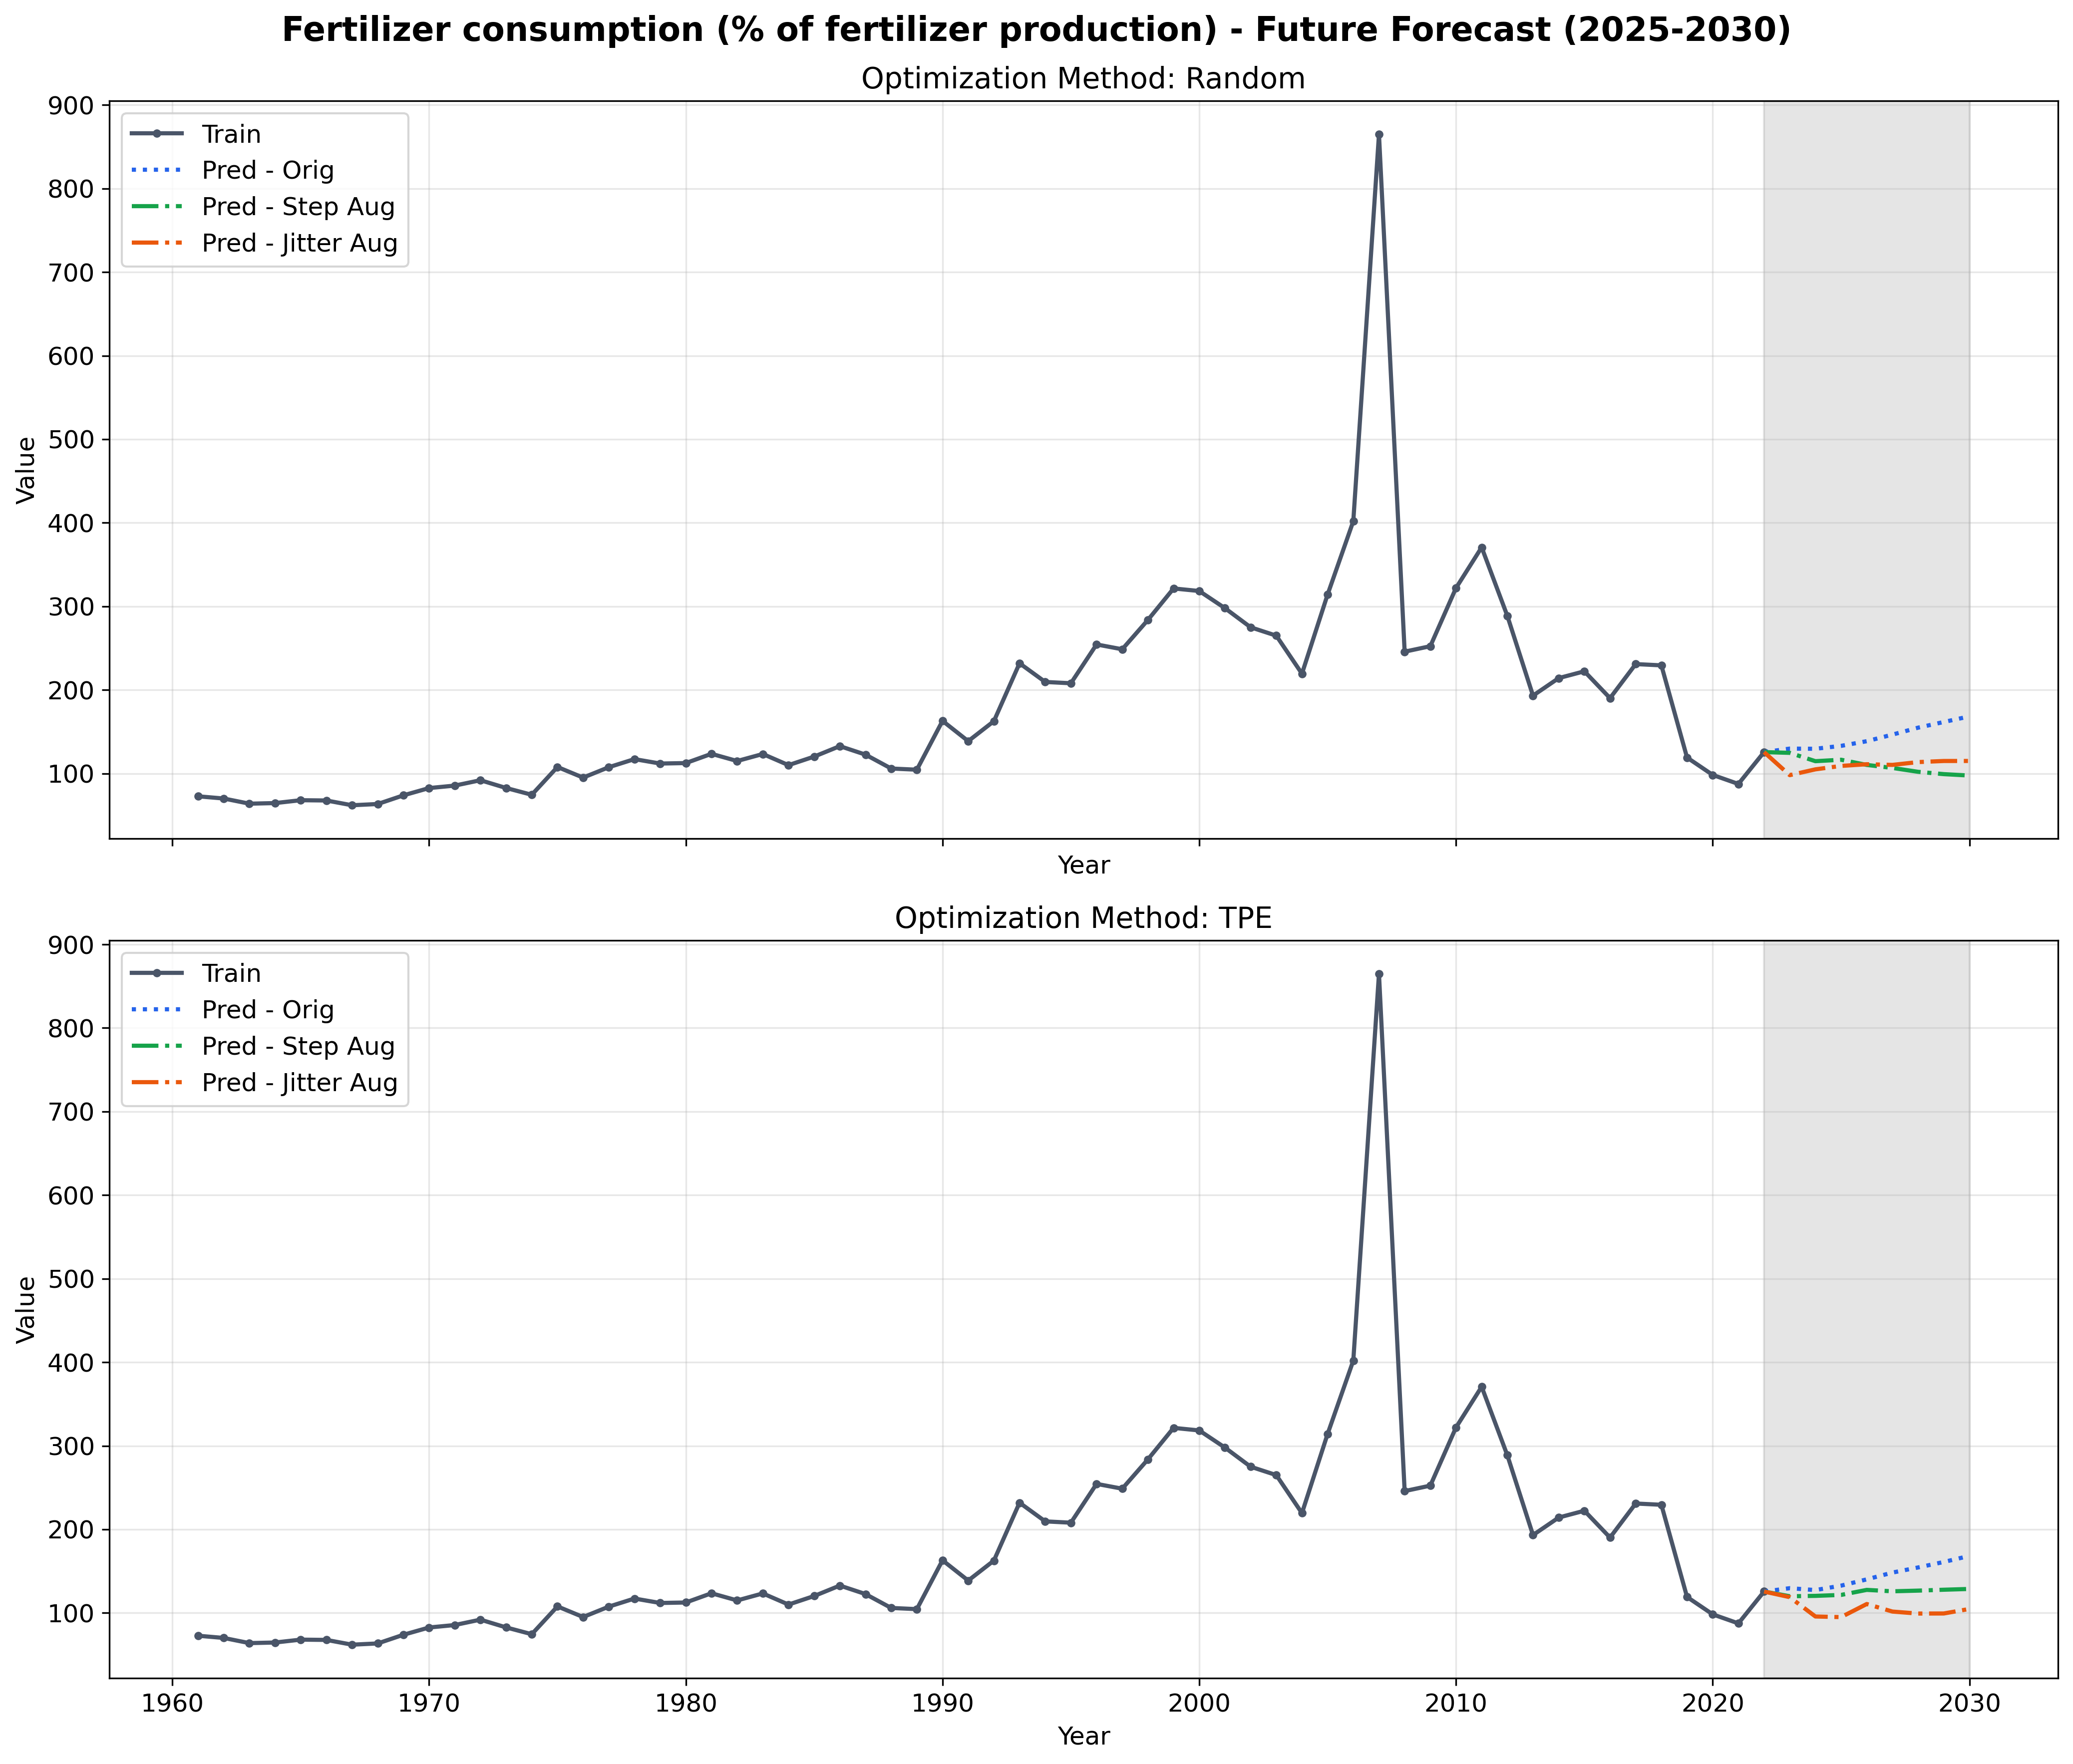

Grafico salvato: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\CNN_2030\FUTURE_CNN_2030_fertilizer_percent.png


In [16]:
for indicator in forecasts_2030.keys():
    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Missing historical subsets for {indicator} -> skip")
        continue

    visual.plot_future_forecasts(
        variable_name=indicator,
        predictions_dict=forecasts_2030,
        train_df=train_orig,
        val_df=val_orig,
        test_df=test_orig,
        model_name="CNN_2030"
    )